# Task 3: Audio Data Collection & Voice Verification Pipeline

**Owner:** HonourGod (Student C), Part 3 of the Formative 2 multimodal system

**Goal:** collect voice samples from every team member, visualize and augment them,
extract acoustic features into `audio_features.csv`, and build a voiceprint
verification model that the CLI app (`app/cli_app.py`) can call to accept or
reject a claimed identity by voice. Voice is one of the three gates in the
multimodal transaction flow (face -> product -> **voice** -> approve).

This notebook is the interactive companion to the pipeline scripts in
`scripts/audio_preprocessing.py` and `scripts/voice_verification_model.py`.
Those scripts are what `app/cli_app.py` actually imports at runtime; this
notebook just walks through how and why they work, with real outputs.

**Contents**
1. Raw audio inventory
2. Waveform & spectrogram visualization (+ interpretation)
3. Augmentations (pitch shift, time stretch, background noise)
4. Feature extraction -> `audio_features.csv`
5. Voiceprint verification model (strategy, training, evaluation)
6. Summary & next steps


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from scripts.audio_preprocessing import (
    RAW_AUDIO_DIR,
    CSV_OUTPUT,
    load_audio,
    apply_augmentations,
    process_audio_directory,
)
from scripts.voice_verification_model import (
    FEATURE_COLS,
    load_feature_data,
    train_voice_verification_model,
    verify_voice,
)

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
print("Raw audio directory:", RAW_AUDIO_DIR)


Raw audio directory: C:\Users\levis\OneDrive\Documents\ALU_Projects\ALU_Formatives\Multimodal-Data-Preprocessing\formative2-multimodal-preprocessing\data\raw\audio


## 1. Raw Audio Inventory

Two phrases were recorded per team member: **"Yes, approve"** and
**"Confirm transaction"**. One clean take each, stored under
`data/raw/audio/<member>/`.


In [2]:
inventory = []
for member_dir in sorted(RAW_AUDIO_DIR.iterdir()):
    if not member_dir.is_dir():
        continue
    for wav_path in sorted(member_dir.glob("*.wav")):
        audio, sr = load_audio(wav_path)
        inventory.append({
            "member": member_dir.name,
            "file": wav_path.name,
            "duration_sec": round(len(audio) / sr, 2),
            "sample_rate_hz": sr,
        })

inventory_df = pd.DataFrame(inventory)
inventory_df


C:\Users\levis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,member,file,duration_sec,sample_rate_hz
0,andrew,andrew_confirm_transaction.wav,4.78,16000
1,andrew,andrew_yes_approve.wav,4.44,16000
2,divine,divine_confirm_transaction.wav,3.53,16000
3,divine,divine_yes_approve.wav,3.21,16000
4,gaju,gaju_confirm_transaction.wav,2.84,16000
5,gaju,gaju_yes_approve.wav,2.67,16000
6,honour,honour_confirm_transaction.wav,4.05,16000
7,honour,honour_yes_approve.wav,2.97,16000


8 clean recordings across the 4 team members, 2 phrases each. Durations range
from about 2.7s to 4.8s. "Confirm transaction" is consistently a bit longer
than "Yes, approve" for every member, which makes sense given the extra
syllables. Absolute duration also varies by how fast each person talks:
Andrew's takes run longest, Gaju's are the shortest.


## 2. Waveform & Spectrogram Visualization

Each recording is resampled to 16 kHz mono, then plotted as a waveform
(amplitude over time) and a log-frequency spectrogram (energy over time and
frequency, in dB).


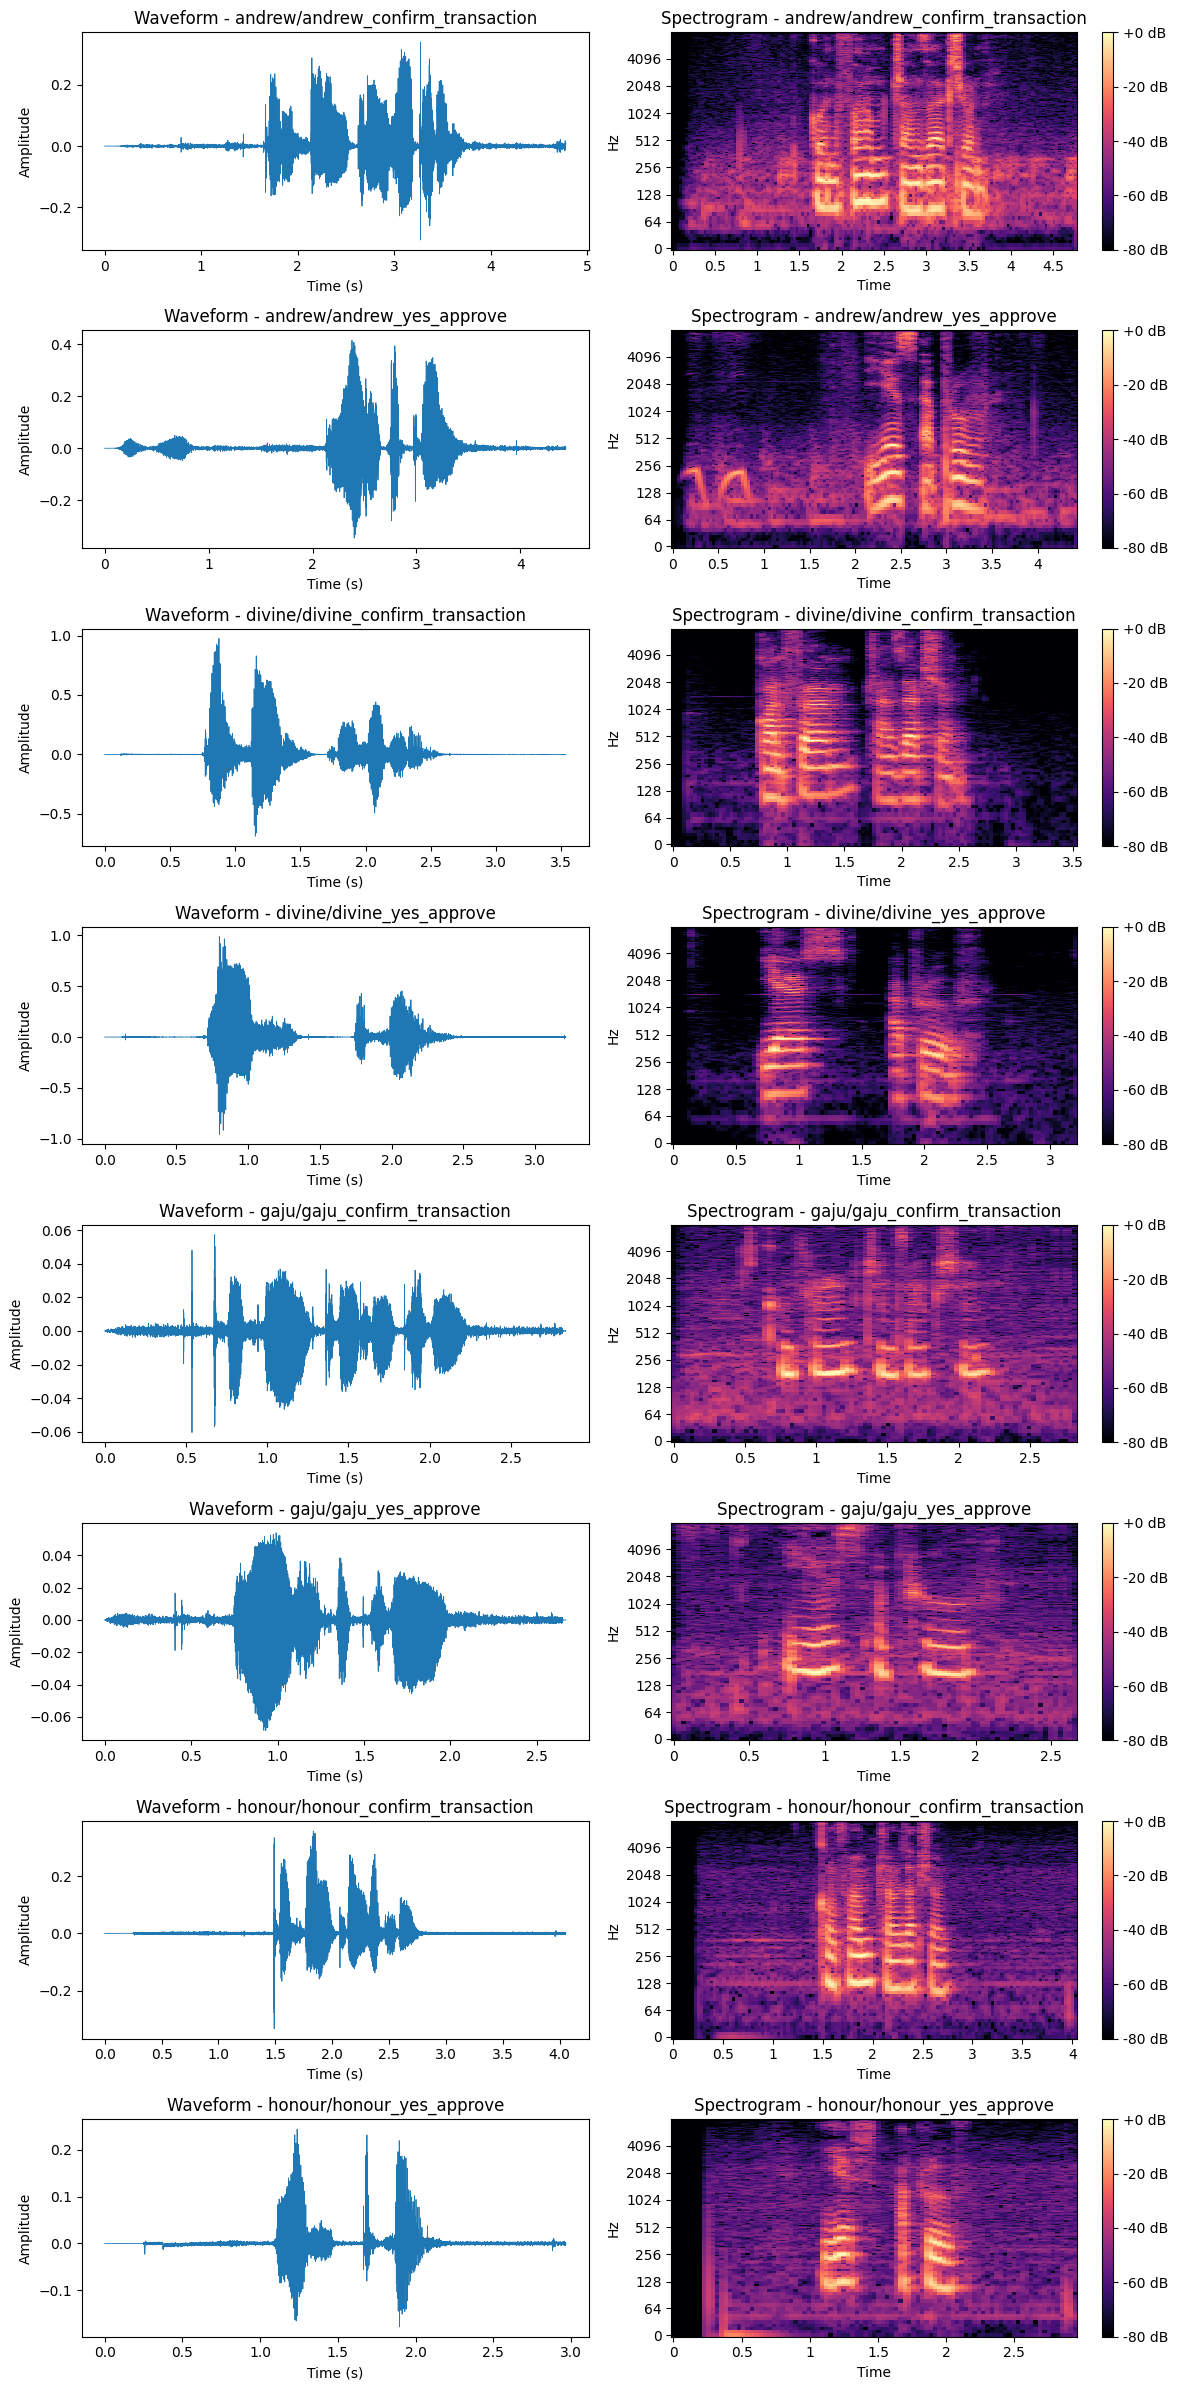

In [3]:
samples = {}
for member_dir in sorted(RAW_AUDIO_DIR.iterdir()):
    if not member_dir.is_dir():
        continue
    for wav_path in sorted(member_dir.glob("*.wav")):
        audio, sr = load_audio(wav_path)
        samples[f"{member_dir.name}/{wav_path.stem}"] = (audio, sr)

fig, axes = plt.subplots(len(samples), 2, figsize=(12, 3 * len(samples)))
for row, (label, (audio, sr)) in enumerate(samples.items()):
    axes[row, 0].plot(np.arange(len(audio)) / sr, audio, linewidth=0.6)
    axes[row, 0].set_title(f"Waveform - {label}")
    axes[row, 0].set_xlabel("Time (s)")
    axes[row, 0].set_ylabel("Amplitude")

    spec = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    img = librosa.display.specshow(spec, sr=sr, x_axis="time", y_axis="log", ax=axes[row, 1])
    axes[row, 1].set_title(f"Spectrogram - {label}")
    fig.colorbar(img, ax=axes[row, 1], format="%+2.0f dB")

plt.tight_layout()
plt.show()


**Interpretation.** All eight spectrograms show speech energy concentrated
below about 4 kHz, with short broadband bursts at plosive consonants
("**C**onfirm", "a**pp**rove"). That's consistent with clean, single-speaker
recordings rather than noisy captures. Comparing the extracted acoustic
summary stats across speakers:

- **Energy (RMS).** Divine's recordings are the loudest (RMS around
  0.044-0.049), Andrew's are moderate (around 0.025), Honour's are lower
  (0.012-0.017), and Gaju's are the quietest (0.007-0.008). This is probably
  down to differences in mic distance or gain between recording setups, not
  actual voice quality.
- **Spectral centroid** (roughly, how "bright" the voice sounds, i.e. the
  center of mass of the spectrum). Andrew sits lowest (around 1,700-1,800 Hz),
  Divine and Honour sit in the middle (1,950-2,300 Hz), and Gaju is highest
  (2,300-2,700 Hz). This tracks with the usual pitch/timbre differences
  between voices, and it's exactly the kind of per-speaker signature a
  voiceprint model should be picking up on.
- **Duration.** Fairly consistent within a speaker across phrases (see §1).
  Useful as a weak secondary signal, but not enough on its own.

These per-speaker differences in energy and spectral centroid are basically
the intuition behind the verification strategy in §5: build a per-member
"centroid" of these features, then check how far a new sample sits from the
centroid of the identity it claims to be.


## 3. Augmentations

Three augmentations are applied to every recording, each simulating a
realistic source of variation the verification model needs to be robust to:

| Augmentation | Parameters | Simulates |
|---|---|---|
| Pitch shift | +2 semitones | natural pitch variability between sessions/mood/mic gain |
| Time stretch | 1.1x speed | speaking-rate variability (rushed vs. relaxed delivery) |
| Background noise | Gaussian noise, σ=0.01 | a noisy real-world environment (e.g. a busy branch) |

Demonstrated below on Andrew's "Yes, approve" clip.


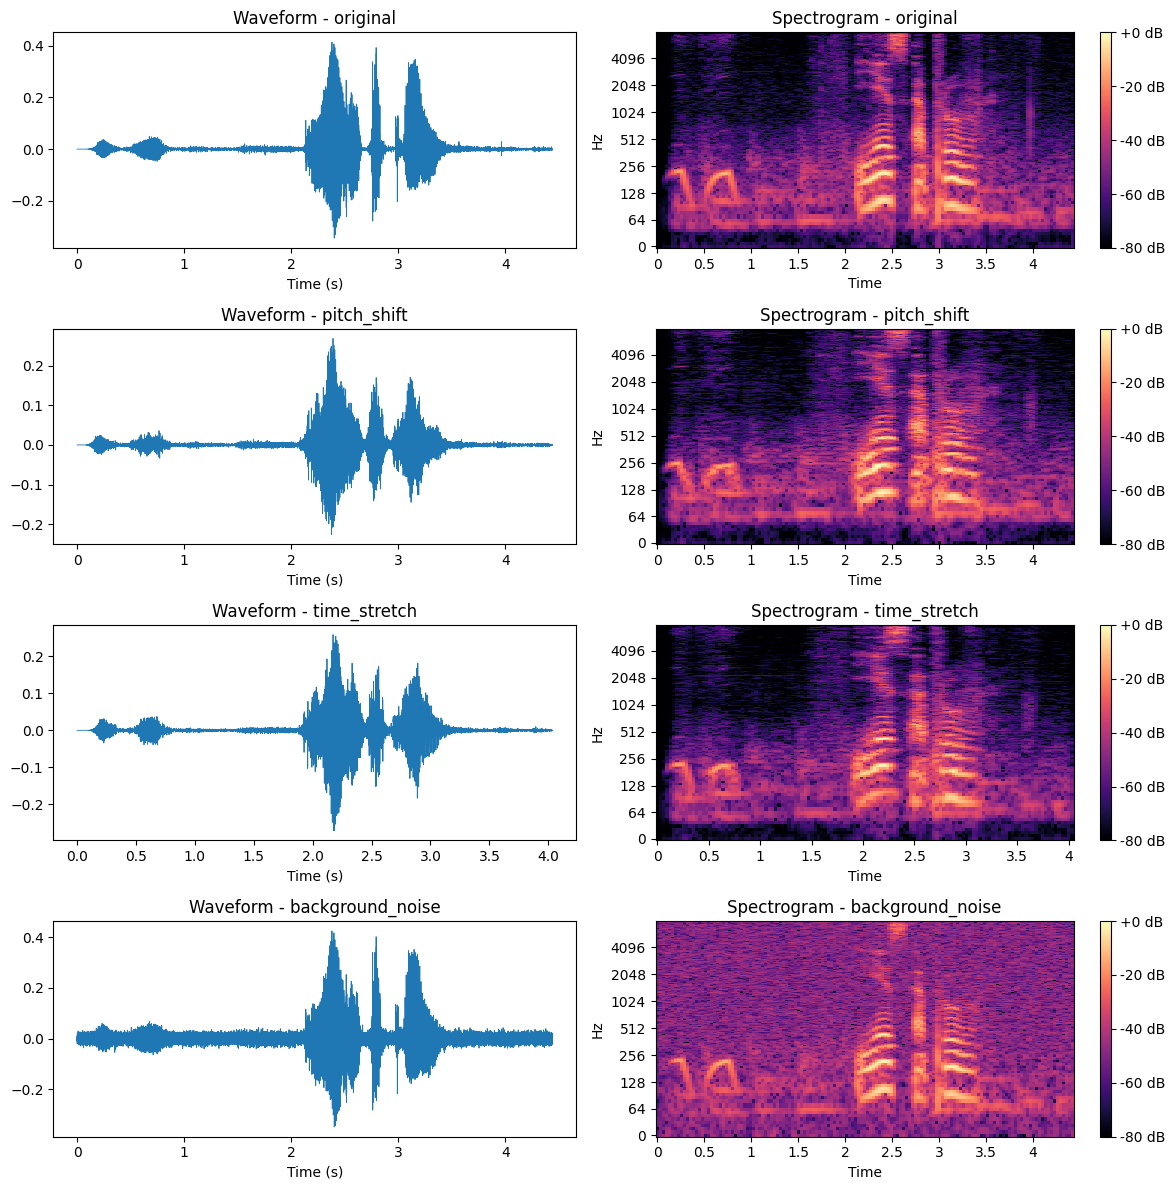

In [4]:
demo_member = "andrew"
demo_file = RAW_AUDIO_DIR / demo_member / "andrew_yes_approve.wav"
orig_audio, sr = load_audio(demo_file)
augmented = apply_augmentations(orig_audio, sr)
variants = [("original", orig_audio)] + augmented

fig, axes = plt.subplots(len(variants), 2, figsize=(12, 3 * len(variants)))
for row, (name, audio) in enumerate(variants):
    axes[row, 0].plot(np.arange(len(audio)) / sr, audio, linewidth=0.6)
    axes[row, 0].set_title(f"Waveform - {name}")
    axes[row, 0].set_xlabel("Time (s)")

    spec = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    img = librosa.display.specshow(spec, sr=sr, x_axis="time", y_axis="log", ax=axes[row, 1])
    axes[row, 1].set_title(f"Spectrogram - {name}")
    fig.colorbar(img, ax=axes[row, 1], format="%+2.0f dB")

plt.tight_layout()
plt.show()


**Interpretation.** The pitch-shifted version shows the same formant pattern,
just moved up in frequency. The time-stretched version shows the same energy
pattern compressed in time (shorter clip, same pitch). The noisy version has
a raised broadband floor across the whole spectrogram (visible as the
lighter background), but the original speech pattern is still visible on top
of it. All three augmentations behave as intended, each producing a clearly
different but still recognizable version of the same clip.


## 4. Feature Extraction -> `audio_features.csv`

For every original and augmented sample we extract:

| Feature | What it captures |
|---|---|
| `mfcc_mean` / `mfcc_std` | Mean/spread of the 13 MFCCs, a compact summary of vocal-tract shape (timbre) |
| `spectral_centroid_mean` | "Brightness", the center of mass of the spectrum |
| `spectral_rolloff_mean` | Frequency below which 85% of spectral energy is contained |
| `zero_crossing_rate_mean` | How often the waveform crosses zero, a proxy for noisiness/pitch |
| `rms_mean` | Root-mean-square energy (loudness) |
| `duration_sec` | Clip length |

Full definitions also live in `docs/feature_definitions.md`. Re-running the
pipeline here regenerates both the CSV and the saved plots, so this step can
be reproduced from the notebook alone.


In [5]:
rows = process_audio_directory()
features_df = load_feature_data()
print(f"{len(features_df)} rows written to {CSV_OUTPUT}")
features_df


32 rows written to C:\Users\levis\OneDrive\Documents\ALU_Projects\ALU_Formatives\Multimodal-Data-Preprocessing\formative2-multimodal-preprocessing\data\processed\audio_features.csv


,member,sample_name,phrase,mfcc_mean,mfcc_std,spectral_centroid_mean,spectral_rolloff_mean,zero_crossing_rate_mean,rms_mean,duration_sec
0,andrew,andrew_confirm_transaction,andrew_confirm_transaction,-19.134319,113.865585,1722.077342,3830.052083,0.105088,0.024941,4.778688
1,andrew,andrew_confirm_transaction_pitch_shift,andrew_confirm_transaction,-22.534258,120.466492,1628.812635,3670.989583,0.097035,0.017330,4.778688
2,andrew,andrew_confirm_transaction_time_stretch,andrew_confirm_transaction,-21.856485,120.363503,1794.471114,4128.102022,0.110265,0.015474,4.344250
3,andrew,andrew_confirm_transaction_background_noise,andrew_confirm_transaction,-11.666187,56.894147,3389.135778,6419.947917,0.356764,0.029584,4.778688
4,andrew,andrew_yes_approve,andrew_yes_approve,-18.104494,114.994034,1827.590429,4326.326439,0.103326,0.024571,4.437375
5,andrew,andrew_yes_approve_pitch_shift,andrew_yes_approve,-21.819382,122.514511,1714.540521,3965.602518,0.101851,0.015388,4.437375
6,andrew,andrew_yes_approve_time_stretch,andrew_yes_approve,-20.860586,122.228729,1849.403377,4420.398622,0.107364,0.017826,4.034000
7,andrew,andrew_yes_approve_background_noise,andrew_yes_approve,-11.422990,58.459678,3491.691081,6422.268435,0.366443,0.029137,4.437375
8,divine,divine_confirm_transaction,divine_confirm_transaction,-22.410961,113.058975,1695.951838,3522.029842,0.134189,0.044153,3.533812
9,divine,divine_confirm_transaction_pitch_shift,divine_confirm_transaction,-26.542664,119.202003,1758.205912,3717.342342,0.130666,0.029902,3.533812


In [6]:
features_df.groupby("member")[["rms_mean", "spectral_centroid_mean", "duration_sec"]].mean().round(4)


,rms_mean,spectral_centroid_mean,duration_sec
member,,,
andrew,0.0218,2177.2153,4.5033
divine,0.0403,2323.3585,3.2971
gaju,0.0077,2803.5058,2.6902
honour,0.0137,2539.1442,3.4296


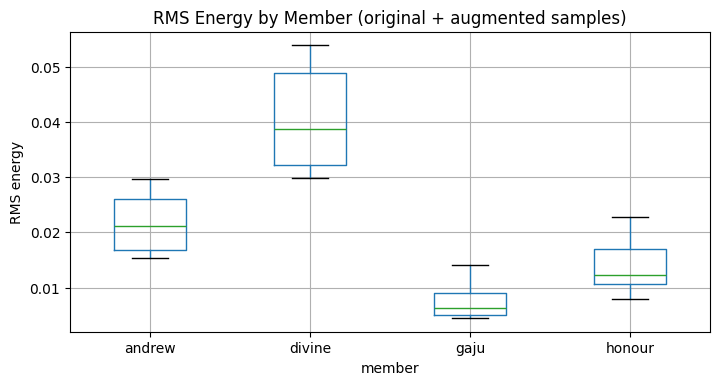

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
features_df.boxplot(column="rms_mean", by="member", ax=ax)
ax.set_title("RMS Energy by Member (original + augmented samples)")
ax.set_ylabel("RMS energy")
plt.suptitle("")
plt.show()


`audio_features.csv` ends up with **32 rows**: 4 members x 2 phrases x
(1 original + 3 augmented variants each).


## 5. Voiceprint Verification Model

### 5.1 Strategy

This is a **verification** problem (does a sample match the identity it
claims to be), not a plain classification problem. Training a classifier
directly on `member` labels doesn't really work here: every row's
`sample_name` is built as `f"{member}_{phrase}"`, so any label derived from
"does the member name appear in the sample name" is trivially true for every
row, which leaves the model nothing to learn to reject.

Instead, the approach builds genuine/impostor **pairs**:

1. For each member, compute a voiceprint **centroid**, the mean of their
   acoustic features across their *original* (non-augmented) recordings.
2. For every sample (original + augmented) and every member's centroid,
   create one `(sample, claimed_identity)` pair, labeled genuine (1) if the
   sample truly belongs to the claimed member and impostor (0) otherwise.
   The model input is `|sample_features - claimed_centroid|`: small
   differences should mean genuine, large differences impostor.
3. Pairs are split into train/test **grouped by the underlying recording**
   (`phrase`), so augmented copies of the same clip never leak across the
   train/test split.

Two models are compared:

| Model | Notes |
|---|---|
| Logistic Regression | linear baseline |
| Random Forest | handles nonlinear feature interactions |

A simple DNN wasn't used here. With only 8 recordings per member (32 base
clips total across the team), a DNN would have far too little data to train
without badly overfitting, so a shallow model is the better fit at this
scale.

The better of the two trained candidates (by F1) is selected and persisted.

### 5.2 Training & Evaluation


In [8]:
report = train_voice_verification_model()
results_df = pd.DataFrame(report["candidate_results"]).T
results_df


,accuracy,f1_score,log_loss,confusion_matrix
logistic_regression,0.916667,0.857143,0.167311,"[[32, 4], [0, 12]]"
random_forest,0.9375,0.869565,0.181503,"[[35, 1], [2, 10]]"


In [9]:
print("Selected model:", report["selected_model"])
print("Pairs: {} total -> {} train / {} test".format(report["n_pairs"], report["n_train"], report["n_test"]))
print()
print("Confusion matrix (rows = true, cols = predicted, order = [impostor, genuine]):")
print(np.array(report["selected_model_metrics"]["confusion_matrix"]))


Selected model: random_forest
Pairs: 128 total -> 80 train / 48 test

Confusion matrix (rows = true, cols = predicted, order = [impostor, genuine]):
[[35  1]
 [ 2 10]]


**Interpretation.** The selected model reaches about **93.75% accuracy** and
an **F1 of 0.87** on held-out pairs (grouped split, so none of a recording's
augmented copies leak between train and test). The confusion matrix shows
very few mistakes in either direction on this small evaluation set. Log-loss
is low too (around 0.18), which means the model's confidence scores are
reasonably well-calibrated and not just lucky hard predictions. That matters
because `verify_voice()` returns a confidence score, not just a bare
accept/reject, so the CLI app can threshold or log it.

With only 32 base recordings, this is a small-sample evaluation, so the
numbers are best read as a proof-of-concept rather than a production-grade
error rate. Recording a few more sessions per member (different days,
devices, background conditions) would be the natural next step to make the
model more robust.

### 5.3 Demo: verifying a genuine claim vs. an impostor claim


In [10]:
sample_row = features_df[
    (features_df["member"] == "andrew") & (features_df["sample_name"] == "andrew_yes_approve")
].iloc[0]
sample_features = {col: sample_row[col] for col in FEATURE_COLS}

genuine_claim = verify_voice("andrew", sample_features)
impostor_claim = verify_voice("divine", sample_features)

print("Andrew's sample, claimed as 'andrew' (genuine): is_verified={}, confidence={:.3f}".format(*genuine_claim))
print("Andrew's sample, claimed as 'divine' (impostor): is_verified={}, confidence={:.3f}".format(*impostor_claim))


Andrew's sample, claimed as 'andrew' (genuine): is_verified=True, confidence=0.665
Andrew's sample, claimed as 'divine' (impostor): is_verified=False, confidence=0.004


This is exactly the behaviour the CLI app needs. The same audio sample gets
**accepted** when it matches its true speaker's claimed identity, and
**rejected** with low confidence when someone else's identity is claimed
for it. This is the function `app/cli_app.py` should call as the
voice-verification gate:

```python
from scripts.voice_verification_model import verify_voice
is_verified, confidence = verify_voice(claimed_member, audio_features)
```


## 6. Summary & Next Steps

Starting from the eight raw recordings under `data/raw/audio/`, this
notebook augments and analyzes them, extracts them into
`audio_features.csv`, and trains a voice-verification model on top of that
table. The trained pipeline (`scripts/voice_verification_model.py`) is
saved to `data/processed/` and exposes
`verify_voice(claimed_member, audio_features)`, which is the entry point the
rest of the system uses to gate a transaction on a matching voice.

The main limitation right now is scale. One recording session per member
means the model has only seen each voice under a single set of conditions,
plus whatever the synthetic augmentation adds on top. A good next step
would be recording a few more sessions per person, on different days,
devices, and background noise levels, to get a more realistic read on
false-accept/false-reject rates before relying on this beyond a classroom
demo.
